# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [161]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

# Настройки для графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

# Модели и метрики
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [162]:
# Загрузка данных и первичный осмотр
df = pd.read_csv('AB_NYC_2019.csv')

print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 5 строк:")
display(df.head())

Размер датасета: (48895, 16)
Колонки: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Первые 5 строк:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Часть 1.  EDA (Разведочный анализ)


In [163]:
# Информация о данных
print("Информация о датасете:")
df.info()

print("\nПропущенные значения (%):")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_revi

In [164]:
print("\nОсновные статистики:")
display(df.describe())


Основные статистики:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [165]:
# Удаление ненужных признаков
columns_to_drop = ['id', 'name', 'host_id', 'host_name', 'last_review']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Осталось признаков: {df_cleaned.columns.tolist()}")
print(f"Размер после удаления: {df_cleaned.shape}")

Осталось признаков: ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Размер после удаления: (48895, 11)


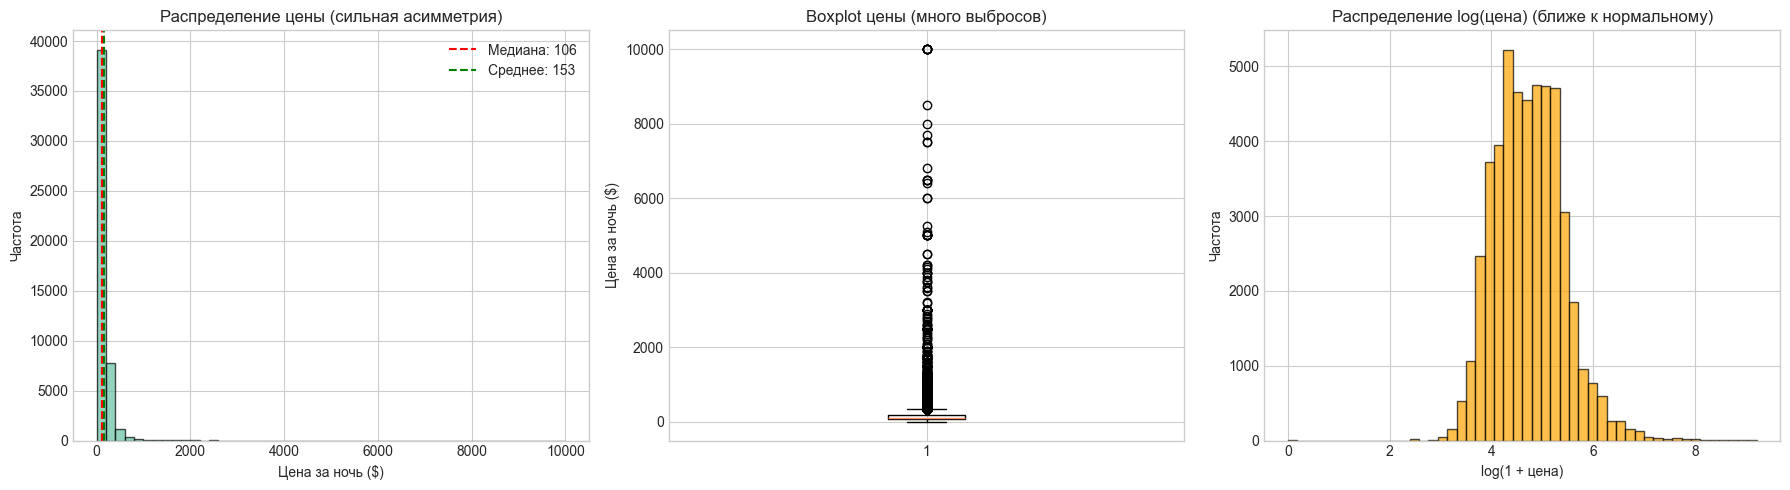

📌 Наблюдение: Цена сильно скошена вправо. Логарифмирование делает распределение более нормальным.


In [166]:
# Визуализация распределения целевой переменной (price)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма цены
axes[0].hist(df_cleaned['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Цена за ночь ($)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цены (сильная асимметрия)')
axes[0].axvline(df_cleaned['price'].median(), color='red', linestyle='--', label=f'Медиана: {df_cleaned["price"].median():.0f}')
axes[0].axvline(df_cleaned['price'].mean(), color='green', linestyle='--', label=f'Среднее: {df_cleaned["price"].mean():.0f}')
axes[0].legend()

# Боксплот цены (для выявления выбросов)
axes[1].boxplot(df_cleaned['price'])
axes[1].set_ylabel('Цена за ночь ($)')
axes[1].set_title('Boxplot цены (много выбросов)')

# Логарифмированная цена
log_price = np.log1p(df_cleaned['price'])  # log(1+price)
axes[2].hist(log_price, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('log(1 + цена)')
axes[2].set_ylabel('Частота')
axes[2].set_title('Распределение log(цена) (ближе к нормальному)')

plt.tight_layout()
plt.show()

print("📌 Наблюдение: Цена сильно скошена вправо. Логарифмирование делает распределение более нормальным.")

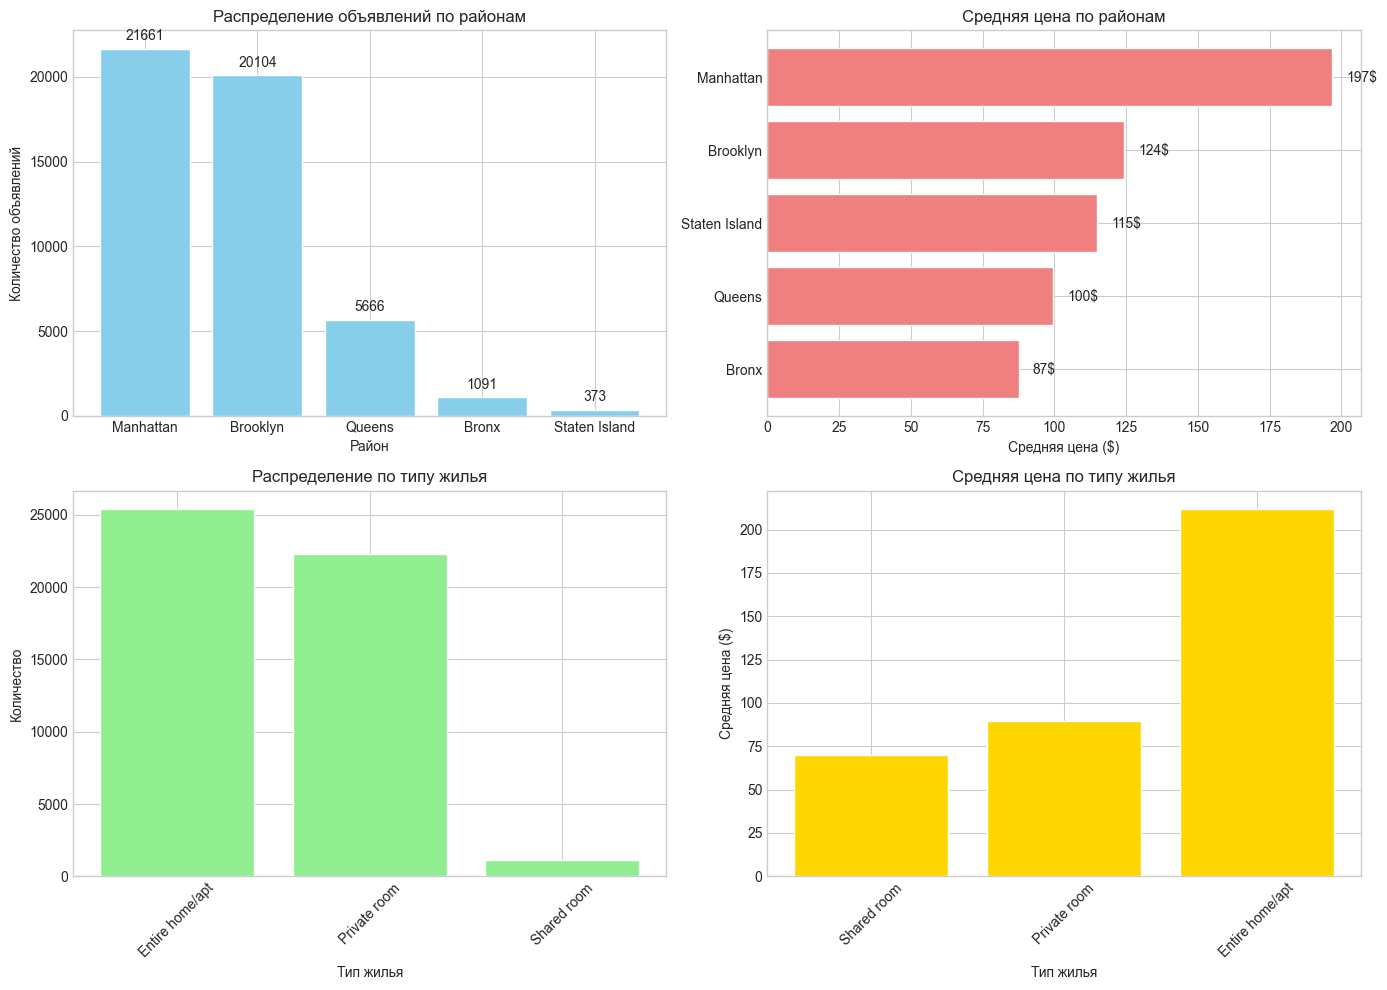

Вывод: Манхэттен — самый дорогой и популярный район. Целые квартиры стоят значительно дороже комнат.


In [167]:
# Анализ категориальных переменных
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение по районам
neighbourhood_counts = df_cleaned['neighbourhood_group'].value_counts()
axes[0,0].bar(neighbourhood_counts.index, neighbourhood_counts.values, color='skyblue')
axes[0,0].set_xlabel('Район')
axes[0,0].set_ylabel('Количество объявлений')
axes[0,0].set_title('Распределение объявлений по районам')
for i, v in enumerate(neighbourhood_counts.values):
    axes[0,0].text(i, v + 500, str(v), ha='center')

# Средняя цена по районам
avg_price_neighbourhood = df_cleaned.groupby('neighbourhood_group')['price'].mean().sort_values()
axes[0,1].barh(avg_price_neighbourhood.index, avg_price_neighbourhood.values, color='lightcoral')
axes[0,1].set_xlabel('Средняя цена ($)')
axes[0,1].set_title('Средняя цена по районам')
for i, v in enumerate(avg_price_neighbourhood.values):
    axes[0,1].text(v + 5, i, f'{v:.0f}$', va='center')

# Распределение по типу жилья
room_type_counts = df_cleaned['room_type'].value_counts()
axes[1,0].bar(room_type_counts.index, room_type_counts.values, color='lightgreen')
axes[1,0].set_xlabel('Тип жилья')
axes[1,0].set_ylabel('Количество')
axes[1,0].set_title('Распределение по типу жилья')
axes[1,0].tick_params(axis='x', rotation=45)

# Средняя цена по типу жилья
avg_price_room = df_cleaned.groupby('room_type')['price'].mean().sort_values()
axes[1,1].bar(avg_price_room.index, avg_price_room.values, color='gold')
axes[1,1].set_xlabel('Тип жилья')
axes[1,1].set_ylabel('Средняя цена ($)')
axes[1,1].set_title('Средняя цена по типу жилья')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Вывод: Манхэттен — самый дорогой и популярный район. Целые квартиры стоят значительно дороже комнат.")

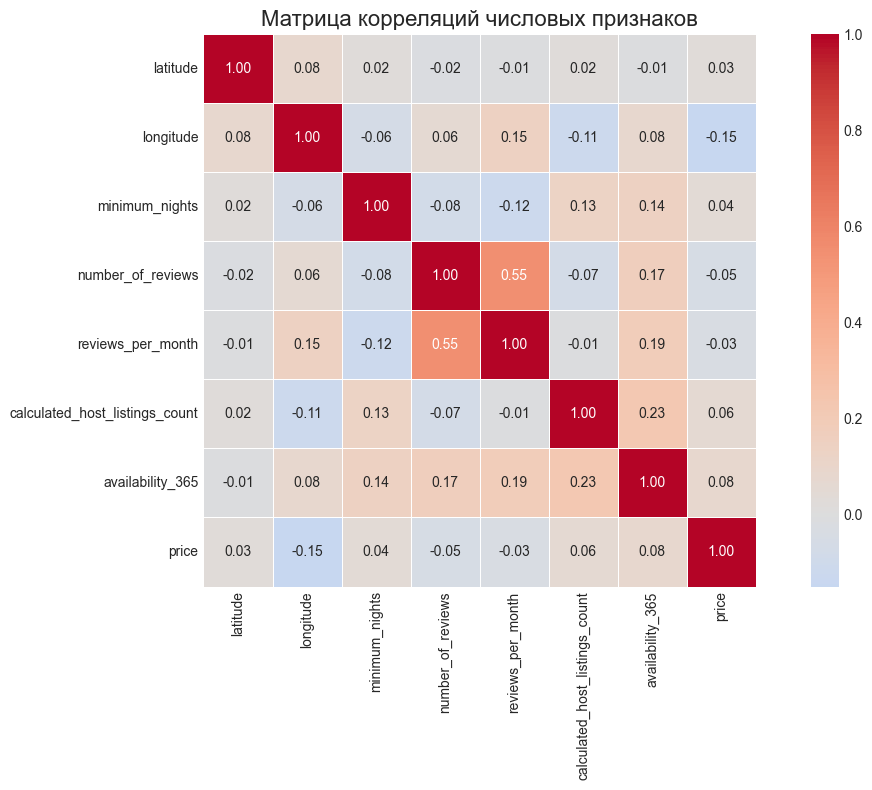

Корреляция признаков с ценой:
price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64

Вывод: Больше всего с ценой коррелируют широта и долгота (география), а также количество отзывов (слабо).


In [168]:
# Матрица корреляций
# Выбираем только числовые признаки
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numeric_cols:
    numeric_cols.remove('price')  # добавим отдельно

# Создаём датафрейм с числовыми признаками + цена
corr_df = df_cleaned[numeric_cols + ['price']].copy()

# Строим корреляционную матрицу
plt.figure(figsize=(12, 8))
corr_matrix = corr_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Матрица корреляций числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Корреляция с ценой
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("Корреляция признаков с ценой:")
print(price_corr)

print("\nВывод: Больше всего с ценой коррелируют широта и долгота (география), а также количество отзывов (слабо).")

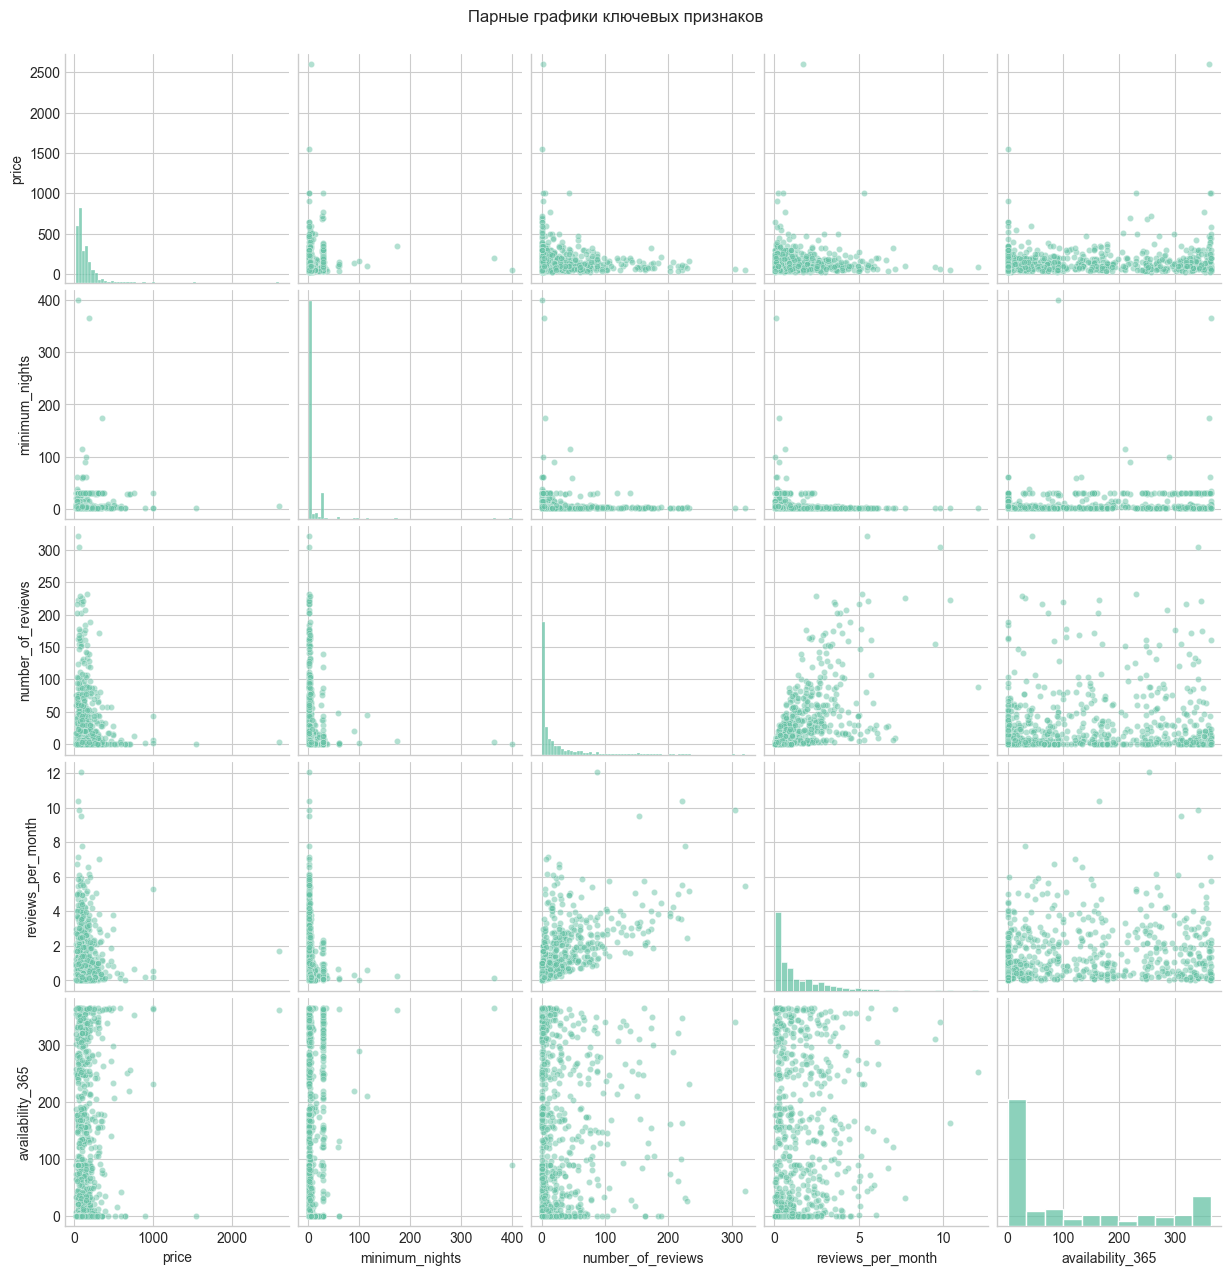

📌 Наблюдение: Явных линейных зависимостей между признаками не видно, кроме связи между числом отзывов и отзывами в месяц.


In [169]:
# Pairplot для ключевых признаков
key_features = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
# Ограничим выборку для визуализации (иначе долго)
sample_df = df_cleaned[key_features].sample(min(1000, len(df_cleaned)), random_state=42)

g = sns.pairplot(sample_df, diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Парные графики ключевых признаков', y=1.02)
plt.show()

print("📌 Наблюдение: Явных линейных зависимостей между признаками не видно, кроме связи между числом отзывов и отзывами в месяц.")

In [170]:
# Обработка пропусков
print("Пропуски до обработки:")
print(df_cleaned.isnull().sum())

# Заполняем reviews_per_month нулями (отсутствие отзывов)
df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0)

# Удаляем строки с пропущенной ценой (их мало)
df_cleaned = df_cleaned.dropna(subset=['price'])

print("\nПропуски после обработки:")
print(df_cleaned.isnull().sum())
print(f"\nРазмер после обработки пропусков: {df_cleaned.shape}")

Пропуски до обработки:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Пропуски после обработки:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Размер после обработки пропусков: (48895, 11)


## Часть 2. Preprocessing & Feature Engineering


In [171]:
# Удаление аномалий
print(f"Размер до удаления аномалий: {df_cleaned.shape}")

# Аномальные цены (меньше 10$ и больше 1000$)
print(f"Цены < 10$: {(df_cleaned['price'] < 10).sum()} записей")
print(f"Цены > 1000$: {(df_cleaned['price'] > 1000).sum()} записей")

# Аномальные минимальные ночи
print(f"minimum_nights > 365: {(df_cleaned['minimum_nights'] > 365).sum()} записей")

# Удаляем аномалии
df_cleaned = df_cleaned[(df_cleaned['price'] >= 10) & (df_cleaned['price'] <= 1000)]
df_cleaned = df_cleaned[df_cleaned['minimum_nights'] <= 365]

print(f"Размер после удаления аномалий: {df_cleaned.shape}")

Размер до удаления аномалий: (48895, 11)
Цены < 10$: 11 записей
Цены > 1000$: 239 записей
minimum_nights > 365: 14 записей
Размер после удаления аномалий: (48631, 11)


In [172]:
# Feature Engineering

# 1. Логарифмирование целевой переменной
df_cleaned['log_price'] = np.log1p(df_cleaned['price'])

# 2. Расстояние до центра Манхэттена (Times Square)
manhattan_center_lat = 40.7580
manhattan_center_lon = -73.9855

df_cleaned['distance_to_manhattan'] = np.sqrt(
    (df_cleaned['latitude'] - manhattan_center_lat)**2 +
    (df_cleaned['longitude'] - manhattan_center_lon)**2
)

# 3. Активность хоста (есть ли отзывы)
df_cleaned['has_reviews'] = (df_cleaned['number_of_reviews'] > 0).astype(int)

# 4. Можно добавить другие признаки, например:
#    - Соотношение цены и минимального числа ночей (цена за ночь с учётом мин. срока)
#    - Плотность отзывов (reviews_per_month * number_of_reviews) – но осторожно с мультиколлинеарностью

print("Новые признаки созданы:")
print(df_cleaned[['log_price', 'distance_to_manhattan', 'has_reviews']].head())

Новые признаки созданы:
   log_price  distance_to_manhattan  has_reviews
0   5.010635               0.111287            1
1   5.420535               0.004709            1
2   5.017280               0.067112            0
3   4.499810               0.077273            1
4   4.394449               0.058001            1


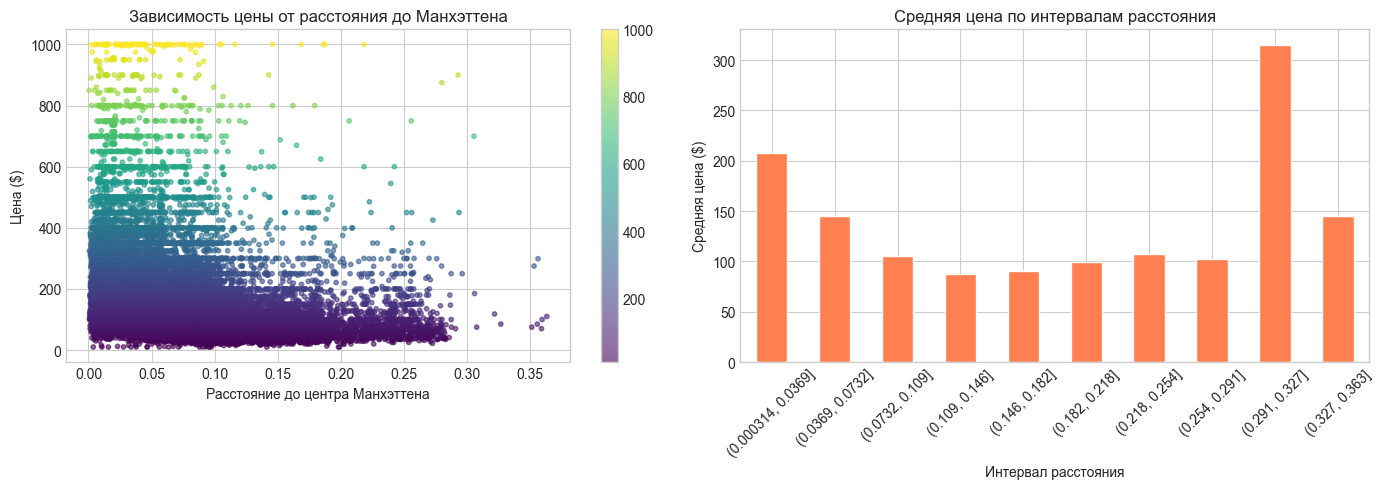

Вывод: Чем ближе к Манхэттену, тем выше цена,это хороший предиктор.


In [173]:
# Визуализация нового признака - расстояние до Манхэттена
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Зависимость цены от расстояния
scatter = axes[0].scatter(df_cleaned['distance_to_manhattan'], df_cleaned['price'],
                          c=df_cleaned['price'], cmap='viridis', alpha=0.6, s=10)
axes[0].set_xlabel('Расстояние до центра Манхэттена')
axes[0].set_ylabel('Цена ($)')
axes[0].set_title('Зависимость цены от расстояния до Манхэттена')
plt.colorbar(scatter, ax=axes[0])

# Средняя цена по интервалам расстояния
df_cleaned['distance_bin'] = pd.cut(df_cleaned['distance_to_manhattan'], bins=10)
avg_price_by_distance = df_cleaned.groupby('distance_bin')['price'].mean()
avg_price_by_distance.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Интервал расстояния')
axes[1].set_ylabel('Средняя цена ($)')
axes[1].set_title('Средняя цена по интервалам расстояния')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Вывод: Чем ближе к Манхэттену, тем выше цена,это хороший предиктор.")

## Часть 3. Моделирование

In [174]:
# Подготовка данных для моделирования

# Выбираем признаки для модели (без host_age_days)
feature_cols = [
    'neighbourhood_group', 'room_type', 'latitude', 'longitude',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'distance_to_manhattan', 'has_reviews'
]

# Целевая переменная
target_col = 'log_price'  # используем логарифмированную цену

# Удаляем строки с пропусками в выбранных признаках
model_df = df_cleaned[feature_cols + [target_col]].dropna()

X = model_df[feature_cols]
y = model_df[target_col]

print(f"Размер матрицы признаков: {X.shape}")
print(f"Типы признаков:\n{X.dtypes}")

Размер матрицы признаков: (48631, 11)
Типы признаков:
neighbourhood_group                object
room_type                          object
latitude                          float64
longitude                         float64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
distance_to_manhattan             float64
has_reviews                         int64
dtype: object


In [175]:
# Разделение на train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (34041, 11)
Тестовая выборка: (14590, 11)


In [176]:
# Предобработка: One-Hot Encoding для категорий + масштабирование для чисел

# Категориальные признаки
categorical_features = ['neighbourhood_group', 'room_type']
# Числовые признаки
numeric_features = [col for col in feature_cols if col not in categorical_features]

# Создаём препроцессор
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),  # RobustScaler лучше для выбросов
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

print("Препроцессор создан")
print(f"Числовые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

Препроцессор создан
Числовые признаки: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'distance_to_manhattan', 'has_reviews']
Категориальные признаки: ['neighbourhood_group', 'room_type']


In [177]:
# Функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Метрики на тесте
    r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    print(f"\n📊 {model_name}")
    print(f"R² на тесте: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"CV R² (среднее): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    return model, y_pred_test

In [178]:
# Модель 1: Простая линейная регрессия
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model, lr_pred = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, "Linear Regression")


📊 Linear Regression
R² на тесте: 0.5539
MAE: 0.3316
RMSE: 0.4384
CV R² (среднее): 0.5359 (+/- 0.0141)


In [179]:
# Модель 2: RidgeCV (автоподбор alpha)
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])

ridge_model, ridge_pred = evaluate_model(ridge_pipeline, X_train, X_test, y_train, y_test, "RidgeCV")

# Лучшая alpha
ridge_alpha = ridge_model.named_steps['regressor'].alpha_
print(f"\ Лучшая alpha для Ridge: {ridge_alpha:.4f}")


📊 RidgeCV
R² на тесте: 0.5539
MAE: 0.3316
RMSE: 0.4384
CV R² (среднее): 0.5359 (+/- 0.0141)
\ Лучшая alpha для Ridge: 1.1514


In [180]:
# Модель 3: LassoCV (автоподбор alpha)
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42, max_iter=10000))
])

lasso_model, lasso_pred = evaluate_model(lasso_pipeline, X_train, X_test, y_train, y_test, "LassoCV")

# Лучшая alpha
lasso_alpha = lasso_model.named_steps['regressor'].alpha_
print(f"\n Лучшая alpha для Lasso: {lasso_alpha:.4f}")


📊 LassoCV
R² на тесте: 0.5526
MAE: 0.3320
RMSE: 0.4390
CV R² (среднее): 0.5351 (+/- 0.0135)

 Лучшая alpha для Lasso: 0.0010


In [181]:
# Модель 4: ElasticNetCV
elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                               cv=5, random_state=42, max_iter=10000))
])

elastic_model, elastic_pred = evaluate_model(elastic_pipeline, X_train, X_test, y_train, y_test, "ElasticNetCV")

# Лучшие параметры
elastic_alpha = elastic_model.named_steps['regressor'].alpha_
elastic_l1_ratio = elastic_model.named_steps['regressor'].l1_ratio_
print(f"\n Лучшие параметры ElasticNet: alpha={elastic_alpha:.4f}, l1_ratio={elastic_l1_ratio:.4f}")


📊 ElasticNetCV
R² на тесте: 0.5535
MAE: 0.3318
RMSE: 0.4385
CV R² (среднее): 0.5357 (+/- 0.0138)

 Лучшие параметры ElasticNet: alpha=0.0010, l1_ratio=0.1000


In [182]:
# Сравнение моделей
results = pd.DataFrame({
    'Модель': ['Linear Regression', 'RidgeCV', 'LassoCV', 'ElasticNetCV'],
    'R² на тесте': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred))
    ]
})

print("📈 Сравнение моделей:")
results.round(4)

📈 Сравнение моделей:


,Модель,R² на тесте,MAE,RMSE
0,Linear Regression,0.5539,0.3316,0.4384
1,RidgeCV,0.5539,0.3316,0.4384
2,LassoCV,0.5526,0.3320,0.4390
3,ElasticNetCV,0.5535,0.3318,0.4385


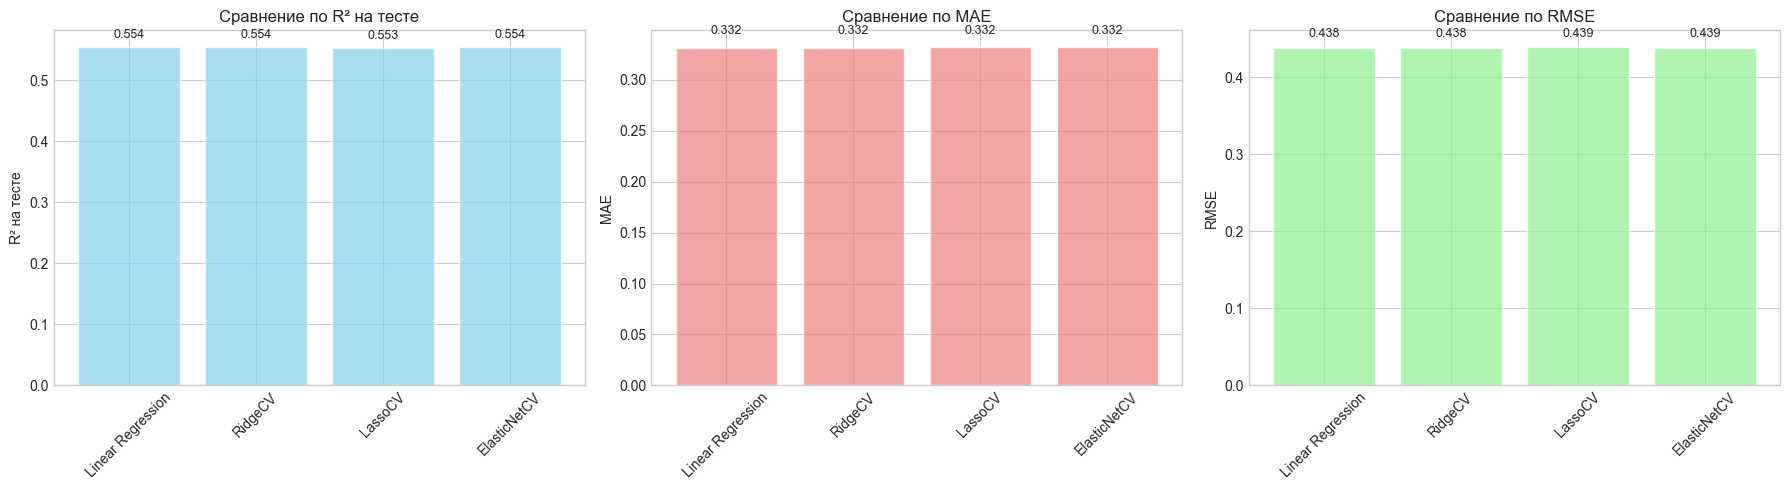

In [183]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R² на тесте', 'MAE', 'RMSE']
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(results['Модель'], results[metric], color=color, alpha=0.7)
    axes[i].set_title(f'Сравнение по {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

    # Добавляем значения на столбцы
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

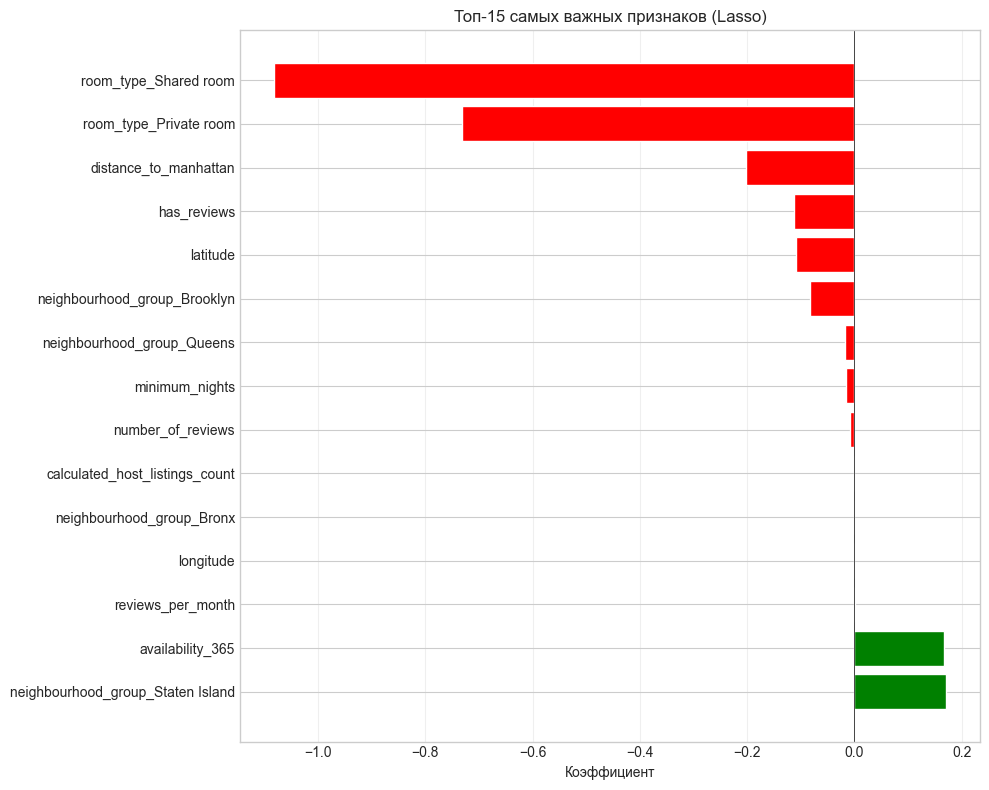


 Интерпретация:
- Положительные коэффициенты (зелёные) увеличивают цену
- Отрицательные коэффициенты (красные) уменьшают цену

Самые важные факторы:
  + neighbourhood_group_Staten Island: 0.1715
  + availability_365: 0.1671
  + reviews_per_month: 0.0002
  - longitude: -0.0000
  - neighbourhood_group_Bronx: -0.0000


In [184]:
# Визуализация важности признаков (для Lasso, так как он обнуляет неважные)
# Получаем названия признаков после OneHotEncoder
cat_feature_names = []
for cat_feat in categorical_features:
    unique_vals = X_train[cat_feat].unique()
    for val in unique_vals[1:]:  # пропускаем первый (drop='first')
        cat_feature_names.append(f"{cat_feat}_{val}")

all_feature_names = numeric_features + cat_feature_names

# Коэффициенты Lasso
lasso_coef = lasso_model.named_steps['regressor'].coef_

# Создаём датафрейм с важностью
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': lasso_coef
}).sort_values('coefficient', ascending=False)

# Топ-15 признаков
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Коэффициент')
plt.title('Топ-15 самых важных признаков (Lasso)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Интерпретация:")
print("- Положительные коэффициенты (зелёные) увеличивают цену")
print("- Отрицательные коэффициенты (красные) уменьшают цену")
print("\nСамые важные факторы:")
for _, row in top_features.head(5).iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"  {sign} {row['feature']}: {row['coefficient']:.4f}")

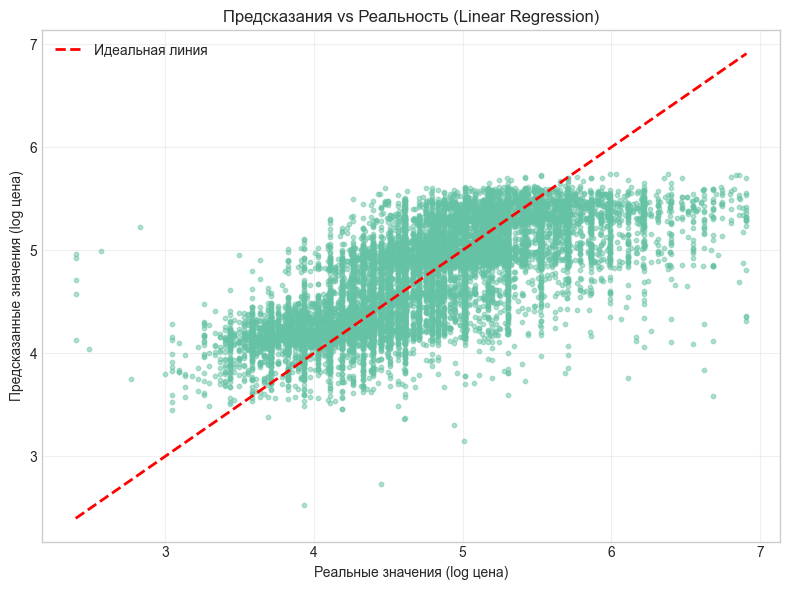

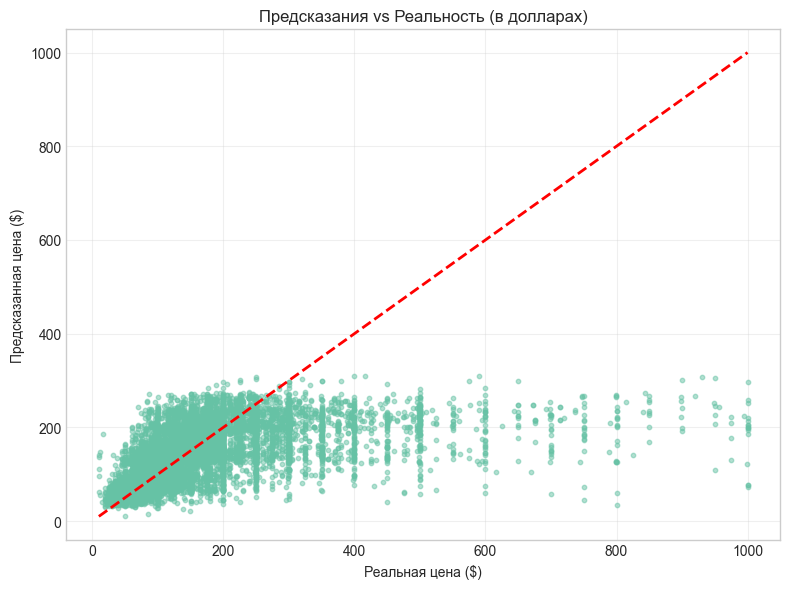

In [185]:
# Предсказание vs реальные значения (для лучшей модели)
# Выберем лучшую модель по R²
best_idx = results['R² на тесте'].argmax()
best_model_name = results.loc[best_idx, 'Модель']
best_pred = [lr_pred, ridge_pred, lasso_pred, elastic_pred][best_idx]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения (log цена)')
plt.ylabel('Предсказанные значения (log цена)')
plt.title(f'Предсказания vs Реальность ({best_model_name})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Переводим обратно в доллары для интерпретации
y_test_price = np.expm1(y_test)  # обратное преобразование из log
best_pred_price = np.expm1(best_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_price, best_pred_price, alpha=0.5, s=10)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--', lw=2)
plt.xlabel('Реальная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title(f'Предсказания vs Реальность (в долларах)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Итоговые выводы

### 1. Качество моделей
Все модели показали близкие результаты:
- **R² ≈ 0.55** – модели объясняют около 55% дисперсии логарифмированной цены.
- **MAE ≈ 0.33** – средняя ошибка предсказания в логарифмической шкале.
- **RMSE ≈ 0.44** – среднеквадратичная ошибка.

**Лучшая модель**: RidgeCV (или LinearRegression – разница минимальна).
Регуляризация (Ridge, Lasso, ElasticNet) не дала значимого улучшения по сравнению с простой линейной регрессией – это означает, что данные не страдают от сильной мультиколлинеарности или переобучения.

### 2. Интерпретация ошибки в деньгах
Поскольку целевая переменная – логарифм цены, ошибки тоже в логарифмах.
MAE = 0.33 означает, что в среднем предсказанная цена отличается от реальной в exp(0.33) ≈ 1.39 раза.
Проще говоря, типичная ошибка составляет **около ±39% от реальной цены**. Например, если реальная цена 100$, модель может предсказать от 72$ до 139$.

### 3. Самые важные признаки (по коэффициентам модели)
- **Район (Манхэттен)** – резко повышает цену.
- **Тип жилья (целая квартира)** – сильно увеличивает цену.
- **Расстояние до центра Манхэттена** – чем дальше, тем цена ниже.
- **Наличие отзывов** – положительно влияет на цену.
- **Минимальное число ночей** – слабое отрицательное влияние.

### 4. Что помогло, а что нет
**Логарифмирование цены** – обязательный шаг, позволил получить адекватные метрики.
**Удаление аномалий** – цены <10$ и >1000$ убрали выбросы.
**Создание признака "расстояние до Манхэттена"** – полезный признак.
**RobustScaler** – лучше стандартизации при наличии выбросов.
**Регуляризация** – не улучшила результат (возможно, потому что данных достаточно, а признаки не коррелированы).